# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 08: RNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_08_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    cache_dir=os.getcwd(),
    extract=True
)

csv_path = os.path.join(os.path.splitext(zip_path)[0], 'jena_climate_2009_2016.csv')

target_col = "T (degC)"

temperature = pd.read_csv(csv_path)[target_col].values.reshape(-1, 1)

temperature

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


array([[-8.02],
       [-8.41],
       [-8.51],
       ...,
       [-3.16],
       [-4.23],
       [-4.82]])

### <font color='#2D9CDB'>Q1) O dataset [Jena Climate](https://www.kaggle.com/datasets/mnassrib/jena-climate) é amplamente utilizado no estudo de redes neurais recorrentes (RNNs), LSTMs e previsão de séries temporais. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o período de coleta dos dados, os tipos de variáveis meteorológicas registradas e por que esse conjunto de dados é adequado para problemas de previsão temporal utilizando redes neurais recorrentes.</font>

**Resposta:** O dataset possui 14 features, como temperatura, pressão atmosférica, umidade, direção do ar, etc, que foram gravadas a cada 10 minutos de 1 de Janeiro de 2009 a 31 de Dezembro de 2016 para descrever o clima da estação meteorológica de Jena, Alemanha. O dataset é útil para problemas de previsão temporal com RNN pela quantidade de dados em sequência e a dependência temporal, já que a temperatura em um momento depende da temperatura anterior a ela.

### <font color='#2D9CDB'>Q2) Utilizando a variável <code>temperature</code>, plote a série temporal completa de temperaturas registradas no dataset. Em seguida, informe a quantidade total de amostras, a temperatura mínima, a temperatura máxima, a temperatura média e o desvio padrão da série. Com base no gráfico obtido, descreva brevemente os padrões observados, comentando sobre possíveis tendências, sazonalidades e variações ao longo do tempo.</font>

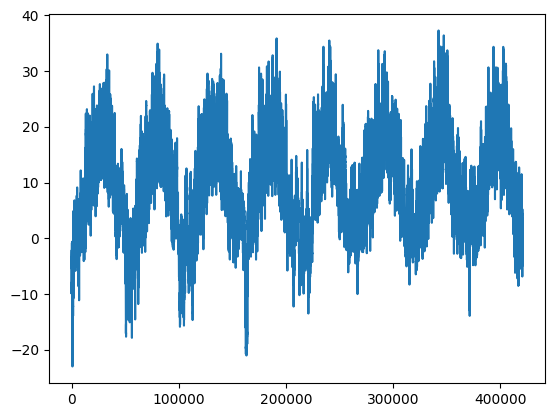

In [4]:
plt.plot(temperature)

In [5]:
print(f'Quantidade de amostras: {len(temperature)}')
print(f'Mínimo de temperatura: {np.min(temperature)}')
print(f'Máximo de temperatura: {np.max(temperature)}')
print(f'Média de temperatura: {np.mean(temperature)}')
print(f'Desvio padrão da temperatura: {np.std(temperature)}')

Quantidade de amostras: 420551
Mínimo de temperatura: -23.01
Máximo de temperatura: 37.28
Média de temperatura: 9.450147354304233
Desvio padrão da temperatura: 8.423355195701777


**Resposta:** Ele possui uma sazonalidade bem definida, tendências locais entre essas sazonalidades e alguns outliers entre essas sazonalidades. Sobre a sazonalidade, elas são coerentes, visto que estamos falando de temperatura de um lugar específico, as estações justificam essas repetições. Sobre as tendências, elas são explicadas pelas próprias estações, uma vez que elas variam a temperatura na mudança. Sobre os outliers, eles provavelmente são de dias em que a temperatura atingiu recordes de mínimo e máximo.

### <font color='#2D9CDB'>Q3) Divida a série temporal em três subconjuntos: treinamento (60%), validação (20%) e teste (20%), preservando a ordem temporal das amostras. Informe a quantidade de amostras em cada subconjunto e explique por que, em problemas de previsão temporal, não é adequado embaralhar os dados antes da divisão.</font>

In [6]:
X_train = temperature[:round(len(temperature)*0.6)]
X_val = temperature[round(len(temperature)*0.6):round(len(temperature)*0.8)]
X_test = temperature[round(len(temperature)*0.8):]
print(f'Quantidade de amostras no treino: {len(X_train)}')
print(f'Quantidade de amostras na validação: {len(X_val)}')
print(f'Quantidade de amostras no teste: {len(X_test)}')

Quantidade de amostras no treino: 252331
Quantidade de amostras na validação: 84110
Quantidade de amostras no teste: 84110


**Resposta:** Em problemas de previsão de amostras temporais, não é adequado se embaralhar as amostras porque a sequência das amostras é importante para o modelo, uma vez que ele carrega as informações, sendo assim, caso a amostra fosse embaralhada, o modelo poderia, por exemplo, aprender que após uma temperatura de verão vem uma temperatura de inverno. Além disso, caso embaralhasse as amostras, ocorreria um Data Leakage, uma vez que o modelo aprenderia com dados futuros.

### <font color='#2D9CDB'>Q4) Normalize os conjuntos de treinamento, validação e teste utilizando a técnica Min-Max Scaling, de forma que os valores fiquem no intervalo [0, 1]. Apresente os valores mínimo e máximo do conjunto de treinamento antes e depois da normalização e explique brevemente por que a normalização é importante para o treinamento de redes neurais.</font>

In [7]:
print(f'Mínimo antes da transformação: {np.min(X_train)}')
print(f'Máximo antes da transformação: {np.max(X_train)}')
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_val = minmax.transform(X_val)
X_test = minmax.transform(X_test)
print(f'Mínimo após transformação: {np.min(X_train)}')
print(f'Máximo após transformação: {np.max(X_train)}')

Mínimo antes da transformação: -23.01
Máximo antes da transformação: 35.86
Mínimo após transformação: 0.0
Máximo após transformação: 1.0


**Resposta:** A normalização dos valores é importante para o modelo para que ele possua um intervalo fixo com o qual trabalhar, sem que os valores possam, teoricamente, variar de menos a mais infinito. Nesse mesmo sentido, caso os valores não estivessem dentro de um intervalo fixo e fosse muito pequenos ou muito grandes, poderíamos cair no problema do sumiço ou explosão do gradiente, o que faria com que o modelo não aprendesse nada.

# <font color='green'><u><b>Parte 2 - Preparação das Séries Temporais</b></u></font>

### <font color='#2D9CDB'>Q5) Para treinar uma LSTM, é necessário organizar a série temporal em sequências de entrada e saídas desejadas. Implemente uma função chamada <code>create_sequences()</code> que utilize uma janela temporal de 30 amostras, de forma que cada entrada seja composta pelas 30 temperaturas anteriores e a saída corresponda à temperatura seguinte. Gere os conjuntos de treinamento, validação e teste e informe as dimensões de <code>X_train</code> e <code>y_train</code>. Explique brevemente o significado de cada dimensão.</font>

In [8]:
def create_sequences(temperature:np.ndarray) -> tuple :
  X = []
  y=[]
  for i in range(len(temperature)-30):
    X.append(temperature[i:i+30])
    y.append(temperature[i+30])
  return np.array(X), np.array(y)

X_train_sequence, y_train_sequence = create_sequences(X_train)
X_val_sequence, y_val_sequence = create_sequences(X_val)
X_test_sequence, y_test_sequence = create_sequences(X_test)
print(f'Dimensões do X_train: {X_train_sequence.shape}')
print(f'Dimensões do y_train: {y_train_sequence.shape}')

Dimensões do X_train: (252301, 30, 1)
Dimensões do y_train: (252301, 1)


**Resposta:** As dimensões geradas representam diferentes coisas. A primeira representa a quantidade de amostras, a segunda representa o tamanho da janela temporal pedida, ou seja, a quantidade de passos de tempo que ele dá e a terceira é a quantidade de features que possui.

### <font color='#2D9CDB'>Q6) Exiba graficamente a primeira sequência presente em <code>X_train</code> e destaque o valor correspondente em <code>y_train</code>. Explique como essa sequência será utilizada pela LSTM para realizar a previsão da próxima temperatura.</font>

Text(0.5, 1.0, 'Plot da primeira sequência')

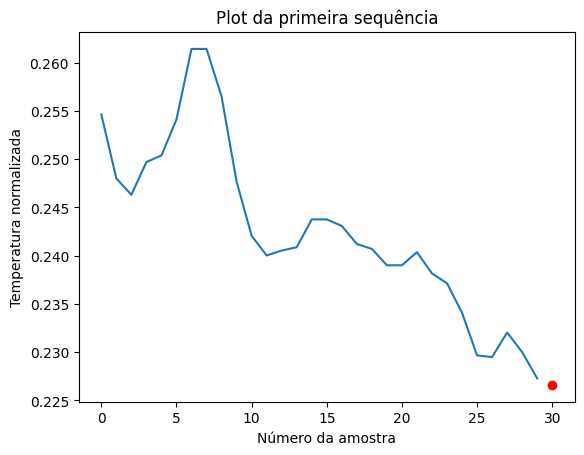

In [9]:
plt.plot(X_train_sequence[0])
plt.scatter(30, y_train_sequence[0], color='red')
plt.xlabel('Número da amostra')
plt.ylabel('Temperatura normalizada')
plt.title('Plot da primeira sequência')

**Resposta:** Em um primeiro momento, a LSTM utiliza essas 30 amostras para realizar a previsão da 31ª, calcula o erro, atualiza os pesos interno e segue para a próxima amostra, fazendo isso até chegar no final e fixar seus pesos internos. Após terminar de fixar seus pesos e aprender, a LSTM passa pelas 30 amostras guardando informação para que depois, utilizando os pesos aprendidos anteriormente, ela possa inferir o valor da 31ª.

# <font color='green'><u><b>Parte 3 - Construindo a Primeira LSTM</b></u></font>

### <font color='#2D9CDB'>Q7) Construa uma rede neural recorrente composta por uma camada LSTM com uma unidade de memória e uma camada de saída totalmente conectada com um neurônio. Utilize a função de perda MSE (<code>mean_squared_error</code>) e o otimizador Adam. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo.</font>

In [10]:
lstm_1 = tf.keras.Sequential(layers=[
    tf.keras.layers.LSTM(input_shape=(30, 1), units=1, ),
    tf.keras.layers.Dense(1,)
])

lstm_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics = ['mean_squared_error']
)

lstm_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

**Resposta:** O modelo possui 14 parâmetros treináveis, sendo eles 12 da camada LSTM, dos quais, cada um dos 4 portões internos possuem 3 parâmetros(1 peso de entrada, 1 peso recorrente e 1 bias), e 2 da Dense, 1 peso e 1 bias.

### <font color='#2D9CDB'>Q8) Treine o modelo por 10 épocas utilizando os conjuntos de treinamento e validação. Em seguida, plote as curvas de perda de treinamento e validação ao longo das épocas. Com base nos gráficos obtidos, descreva brevemente o comportamento do treinamento e indique se há evidências de sobreajuste (overfitting) ou problemas de generalização.</font>

In [11]:
history_lstm_1 = lstm_1.fit(
    X_train_sequence, y_train_sequence,
    epochs = 10,
    validation_data=(X_val_sequence, y_val_sequence)
)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - loss: 0.0212 - mean_squared_error: 0.0212 - val_loss: 7.7854e-05 - val_mean_squared_error: 7.7854e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 5.5651e-05 - mean_squared_error: 5.5651e-05 - val_loss: 3.1378e-05 - val_mean_squared_error: 3.1378e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 2.8318e-05 - mean_squared_error: 2.8318e-05 - val_loss: 2.4171e-05 - val_mean_squared_error: 2.4171e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 2.1298e-05 - mean_squared_error: 2.1298e-05 - val_loss: 2.1430e-05 - val_mean_squared_error: 2.1430e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.7997e-05 - mean_squared_error: 1.7997e-05 - val_loss: 1.9526e-05 - val_mean_squared_error: 1.9526e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step - loss: 1.6216e-05 - mean_squared_error: 1.6216e-05 - val_loss: 1.8008e-05 - val_mean_squared_error: 1.8008e-05
Epoch 

Text(0.5, 1.0, 'Loss nos conjuntos para a LSTM')

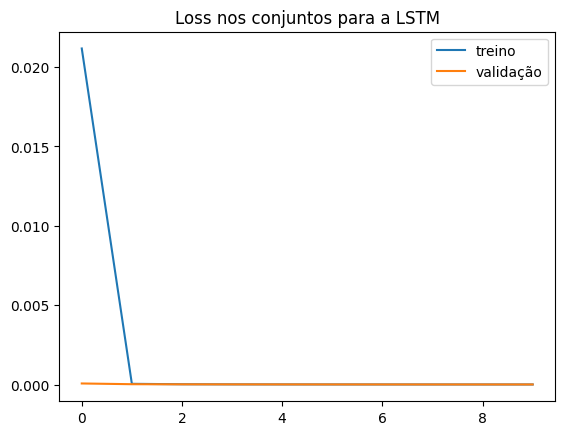

In [12]:
plt.plot(history_lstm_1.history['loss'], label='treino')
plt.plot(history_lstm_1.history['val_loss'], label = 'validação')
plt.legend()
plt.title('Loss nos conjuntos para a LSTM')

**Resposta:** O modelo possui uma Loss muito baixa, tanto para o treino quanto para validação, o que indica que não há um overfitting, mas que o modelo acerta muito. Dado o conjunto de dados que temos, que são temperaturas de um mesmo lugar a cada 10 minutos, como a temperatura em si não muda muito a cada minuto, a generalização do modelo faz com que o valor esteja muito próximo da realidade, se tornando uma estrutura muito favorável, que faz com que o erro médio quadrático não seja tão alto.

### <font color='#2D9CDB'>Q9) Avalie o modelo utilizando o conjunto de teste e reporte o valor do erro quadrático médio (MSE). Em seguida, explique brevemente o que essa métrica representa no contexto do problema de previsão de temperatura.</font>

In [13]:
resultados_1 = lstm_1.evaluate(x=X_test_sequence, y=y_test_sequence)
print(f'A MSE foi de: {resultados_1[1]}')

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.6757e-05 - mean_squared_error: 1.6757e-05
A MSE foi de: 1.6757081539253704e-05


**Resposta:** A média do erro ao quadrado é de 1.6757e-05, o que significa que o ao pegar o erro em cada ponto, elevar tudo ao quadrado,para eliminar negativos, e tirar a média de todos esses erros, ele erra 1.6757e-05. Isso significa que ele erra em média por milésimos dentro da escala normalizada de 0 a 1, o que significa que o modelo está acertando muito.

### <font color='#2D9CDB'>Q10) Utilize o modelo treinado para gerar previsões no conjunto de teste. Plote em um mesmo gráfico os valores reais e previstos para as 100 primeiras amostras do conjunto de teste e descreva brevemente a qualidade das previsões obtidas.</font>

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


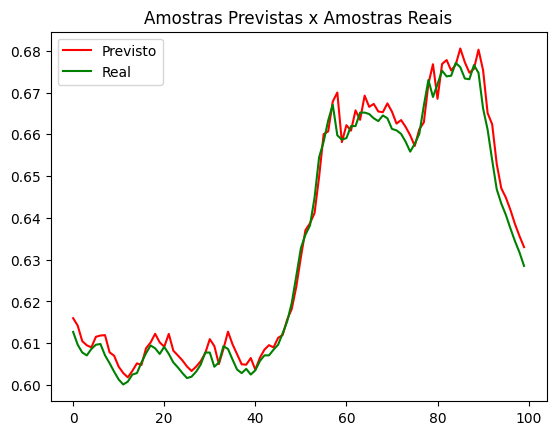

In [14]:
amostras_x = X_test_sequence[:100]
amostras_y = y_test_sequence[:100]
predicao_1 = lstm_1.predict(amostras_x)
plt.plot(predicao_1, 'r', label='Previsto')
plt.plot(amostras_y, 'g', label='Real')
plt.title('Amostras Previstas x Amostras Reais')
plt.legend()

**Resposta:** Pelo gráfico, é possível notar que as predições estão muito próximas dos valores reais, seguindo o mesmo padrão de curva, porém com valores um pouco abaixo ou um pouco acima. Isso mostra que o modelo está acertando bem, como era previsto pelo Loss.

# <font color='green'><u><b>Parte 4 - Comparação de Arquiteturas</b></u></font>

### <font color='#2D9CDB'>Q11) Modifique a arquitetura da rede para utilizar 10 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [15]:
lstm_2 = tf.keras.Sequential(layers=[
    tf.keras.layers.LSTM(input_shape=(30, 1), units=10, ),
    tf.keras.layers.Dense(1,)
])

lstm_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics = ['mean_squared_error']
)

lstm_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_lstm_2 = lstm_2.fit(
    X_train_sequence, y_train_sequence,
    epochs = 10,
    validation_data=(X_val_sequence, y_val_sequence)
)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - loss: 0.0019 - mean_squared_error: 0.0019 - val_loss: 5.0448e-05 - val_mean_squared_error: 5.0448e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 2.8084e-05 - mean_squared_error: 2.8084e-05 - val_loss: 2.3275e-05 - val_mean_squared_error: 2.3275e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.5225e-05 - mean_squared_error: 1.5225e-05 - val_loss: 1.5206e-05 - val_mean_squared_error: 1.5206e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.3897e-05 - mean_squared_error: 1.3897e-05 - val_loss: 1.4326e-05 - val_mean_squared_error: 1.4326e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.3720e-05 - mean_squared_error: 1.3720e-05 - val_loss: 1.1896e-05 - val_mean_squared_error: 1.1896e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.3573e-05 - mean_squared_error: 1.3573e-05 - val_loss: 1.1448e-05 - val_mean_squared_error: 1.1448e-05
Epoch 

In [17]:
resultados_2 = lstm_2.evaluate(x=X_test_sequence, y=y_test_sequence)
print(f'A MSE foi de: {resultados_2[1]}')

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.2235e-05 - mean_squared_error: 1.2235e-05
A MSE foi de: 1.2235405847604852e-05


**Resposta:** A quantidade de parâmetros treináveis é de 491. O MSE obtido foi de 1.2235e-05.

### <font color='#2D9CDB'>Q12) Repita o experimento utilizando 20 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [18]:
lstm_3 = tf.keras.Sequential(layers=[
    tf.keras.layers.LSTM(input_shape=(30, 1), units=20, ),
    tf.keras.layers.Dense(1,)
])

lstm_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics = ['mean_squared_error']
)

lstm_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_lstm_3 = lstm_3.fit(
    X_train_sequence, y_train_sequence,
    epochs = 10,
    validation_data=(X_val_sequence, y_val_sequence)
)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 52s 7ms/step - loss: 1.9822e-04 - mean_squared_error: 1.9822e-04 - val_loss: 4.5756e-05 - val_mean_squared_error: 4.5756e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 2.2482e-05 - mean_squared_error: 2.2482e-05 - val_loss: 2.1459e-05 - val_mean_squared_error: 2.1459e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 52s 7ms/step - loss: 1.4263e-05 - mean_squared_error: 1.4263e-05 - val_loss: 1.5705e-05 - val_mean_squared_error: 1.5705e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 52s 7ms/step - loss: 1.3755e-05 - mean_squared_error: 1.3755e-05 - val_loss: 1.1698e-05 - val_mean_squared_error: 1.1698e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.3484e-05 - mean_squared_error: 1.3484e-05 - val_loss: 1.1384e-05 - val_mean_squared_error: 1.1384e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.3296e-05 - mean_squared_error: 1.3296e-05 - val_loss: 1.1342e-05 - val_mean_squared_error: 1.1342e-0

In [20]:
resultados_3 = lstm_3.evaluate(x=X_test_sequence, y=y_test_sequence)
print(f'A MSE foi de: {resultados_3[1]}')

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.3172e-05 - mean_squared_error: 1.3172e-05
A MSE foi de: 1.3171782484278083e-05


**Resposta:** A quantidade de parâmetros treináveis é de 1781. O MSE obtido foi de 1.3171e-05.

### <font color='#2D9CDB'>Q13) Compare os modelos com 1, 10 e 20 unidades na camada LSTM em termos de número de parâmetros treináveis e desempenho no conjunto de teste. Organize os resultados em uma tabela contendo a quantidade de unidades LSTM, o número de parâmetros treináveis e o valor de MSE. Com base nos resultados obtidos, discuta brevemente a relação entre a complexidade do modelo e sua capacidade preditiva.</font>

In [32]:
dados_experimentos = {
    'Modelo': [
        'LSTM 1',
        'LSTM 2',
        'LSTM 3'
    ],
    'Unidade de Memória': [
        1,
        10,
        20
    ],
    'Quantidade de parâmetros traináveis':[
        lstm_1.count_params(),
        lstm_2.count_params(),
        lstm_3.count_params()
    ],
    'MSE': [
        resultados_1[1],
        resultados_2[1],
        resultados_3[1]
    ]
}
pd.options.display.float_format = '{:.4e}'.format
df_resultados = pd.DataFrame(dados_experimentos)
df_resultados = df_resultados.set_index('Modelo')
df_resultados

,Unidade de Memória,Quantidade de parâmetros traináveis,MSE
Modelo,,,
LSTM 1,1,14,1.6757e-05
LSTM 2,10,491,1.2235e-05
LSTM 3,20,1781,1.3172e-05


**Resposta:** Dados os resultados, aumentar de 1 para 10 unidades trouxe uma melhora notável na capacidade preditiva(1.6757e-05 para 1.2235e-05), mas aumentar de 10 para 20 trouxe uma queda na capacidade preditiva(1.2235e-05 para 1.3172e-05). Dito isso, é razoável imaginar que pode ser que aumentar as unidades de memória além disso possa não necessariamente impactar negativamente no modelo, mas o custo computacional disso só seria justificável caso o requisito de projeto fosse um MSE menor do que aquele já obtido.

# <font color='green'><u><b>Parte 5 - Influência da Janela Temporal</b></u></font>

### <font color='#2D9CDB'>Q14) Repita o experimento utilizando uma janela temporal de 15 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [22]:
def create_sequences_15(temperature:np.ndarray) -> tuple :
  X = []
  y=[]
  for i in range(len(temperature)-15):
    X.append(temperature[i:i+15])
    y.append(temperature[i+15])
  return np.array(X), np.array(y)

X_train_sequence_15, y_train_sequence_15 = create_sequences_15(X_train)
X_val_sequence_15, y_val_sequence_15 = create_sequences_15(X_val)
X_test_sequence_15, y_test_sequence_15 = create_sequences_15(X_test)
print(f'Dimensões do X_train: {X_train_sequence_15.shape}')
print(f'Dimensões do y_train: {y_train_sequence_15.shape}')

Dimensões do X_train: (252316, 15, 1)
Dimensões do y_train: (252316, 1)


In [23]:
lstm_4 = tf.keras.Sequential(layers=[
    tf.keras.layers.LSTM(input_shape=(15, 1), units=10, ),
    tf.keras.layers.Dense(1,)
])

lstm_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics = ['mean_squared_error']
)

lstm_4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_lstm_4 = lstm_4.fit(
    X_train_sequence_15, y_train_sequence_15,
    epochs = 10,
    validation_data=(X_val_sequence_15, y_val_sequence_15)
)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - loss: 7.2900e-04 - mean_squared_error: 7.2900e-04 - val_loss: 3.3382e-05 - val_mean_squared_error: 3.3382e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 2.6628e-05 - mean_squared_error: 2.6628e-05 - val_loss: 2.1241e-05 - val_mean_squared_error: 2.1241e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.6478e-05 - mean_squared_error: 1.6478e-05 - val_loss: 1.6149e-05 - val_mean_squared_error: 1.6149e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.3800e-05 - mean_squared_error: 1.3800e-05 - val_loss: 1.2593e-05 - val_mean_squared_error: 1.2593e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.3529e-05 - mean_squared_error: 1.3529e-05 - val_loss: 1.1515e-05 - val_mean_squared_error: 1.1515e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 1.3415e-05 - mean_squared_error: 1.3415e-05 - val_loss: 1.1477e-05 - val_mean_squared_error: 1.1477e-0

In [25]:
resultados_4 = lstm_4.evaluate(x=X_test_sequence_15, y=y_test_sequence_15)
print(f'A MSE foi de: {resultados_4[1]}')

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.2338e-05 - mean_squared_error: 1.2338e-05
A MSE foi de: 1.2338035958237015e-05


**Resposta:** O MSE obtido pelo modelo foi de 1.2338e-05.

### <font color='#2D9CDB'>Q15) Repita o experimento utilizando uma janela temporal de 60 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [26]:
def create_sequences_60(temperature:np.ndarray) -> tuple :
  X = []
  y=[]
  for i in range(len(temperature)-60):
    X.append(temperature[i:i+60])
    y.append(temperature[i+60])
  return np.array(X), np.array(y)

X_train_sequence_60, y_train_sequence_60 = create_sequences_60(X_train)
X_val_sequence_60, y_val_sequence_60 = create_sequences_60(X_val)
X_test_sequence_60, y_test_sequence_60 = create_sequences_60(X_test)
print(f'Dimensões do X_train: {X_train_sequence_60.shape}')
print(f'Dimensões do y_train: {y_train_sequence_60.shape}')

Dimensões do X_train: (252271, 60, 1)
Dimensões do y_train: (252271, 1)


In [27]:
lstm_5 = tf.keras.Sequential(layers=[
    tf.keras.layers.LSTM(input_shape=(60, 1), units=10, ),
    tf.keras.layers.Dense(1,)
])

lstm_5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics = ['mean_squared_error']
)

lstm_5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history_lstm_5 = lstm_5.fit(
    X_train_sequence_60, y_train_sequence_60,
    epochs = 10,
    validation_data=(X_val_sequence_60, y_val_sequence_60)
)

Epoch 1/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 61s 8ms/step - loss: 0.0011 - mean_squared_error: 0.0011 - val_loss: 4.3134e-05 - val_mean_squared_error: 4.3134e-05
Epoch 2/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 60s 8ms/step - loss: 3.0010e-05 - mean_squared_error: 3.0010e-05 - val_loss: 2.5355e-05 - val_mean_squared_error: 2.5355e-05
Epoch 3/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 60s 8ms/step - loss: 1.5889e-05 - mean_squared_error: 1.5889e-05 - val_loss: 1.7338e-05 - val_mean_squared_error: 1.7338e-05
Epoch 4/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - loss: 1.3708e-05 - mean_squared_error: 1.3708e-05 - val_loss: 1.2446e-05 - val_mean_squared_error: 1.2446e-05
Epoch 5/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 1.3496e-05 - mean_squared_error: 1.3496e-05 - val_loss: 1.1788e-05 - val_mean_squared_error: 1.1788e-05
Epoch 6/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 59s 7ms/step - loss: 1.3402e-05 - mean_squared_error: 1.3402e-05 - val_loss: 1.1743e-05 - val_mean_squared_error: 1.1743e-05
Epoch 

In [29]:
resultados_5 = lstm_5.evaluate(x=X_test_sequence_60, y=y_test_sequence_60)
print(f'A MSE foi de: {resultados_5[1]}')

2627/2627 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.2241e-05 - mean_squared_error: 1.2241e-05
A MSE foi de: 1.2240619980730116e-05


**Resposta:** O MSE obtido pelo modelo foi de 1.2241e-05.

### <font color='#2D9CDB'>Q16) Compare os resultados obtidos para janelas temporais de 15, 30 e 60 amostras utilizando uma camada LSTM com 10 unidades. Organize os resultados em uma tabela contendo o tamanho da janela temporal, o valor de MSE e uma estimativa do tempo médio de treinamento por época (dica: utilize os valores exibidos nos logs de treinamento). Com base nos resultados, discuta brevemente o impacto do tamanho da janela temporal no desempenho e no custo computacional do modelo.</font>

In [40]:
dados_experimentos = {
    'Modelo': [
        'LSTM 4',
        'LSTM 2',
        'LSTM 5'
    ],
    'Janela Temporal': [
        15,
        30,
        60
    ],
    'MSE': [
        resultados_4[1],
        resultados_2[1],
        resultados_5[1]
    ],
    'Estimativa de tempo por época':[
      47.5,
      54.6,
      63.5

    ]
}

df_resultados = pd.DataFrame(dados_experimentos)
df_resultados = df_resultados.set_index('Modelo')
df_resultados.style.format({
    'MSE': '{:.4e}',
    'Estimativa de tempo por época': '{:.1f}'
})

,Janela Temporal,MSE,Estimativa de tempo por época
Modelo,,,
LSTM 4,15,1.2338e-05,47.5
LSTM 2,30,1.2235e-05,54.6
LSTM 5,60,1.2241e-05,63.5


**Resposta:** Diminuir a janela temporal de 30 para 15 trouxe uma queda na capacidade preditiva do modelo(1.2235e-05 para 1.2338e-05) porém trouxe uma queda na estimativa de tempo médio por época(54.6s para 47.5s). Do mesmo modo, aumentar de 30 para 60 trouxe um aumento na estimativa de tempo médio por época(54.6s para 63.5s) porém trouxe uma ligeira queda de desempenho(1.2235e-05 para 1.2241e-05). Assim, é justificável dizer que o custo computacional não necessariamente se traduz em capacidade preditiva ao modelo, logo, o melhor é manter em uma janela temporal de 30 unidades, que tem um custo computacional maior que a de 15, mas um desempenho melhor e um custo menor que a 60 e um desempenho igualmente melhor.

# <font color='green'><u><b>Parte 6 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q17) Com base em todos os experimentos realizados nesta atividade, discuta os fatores que mais influenciaram o desempenho do modelo. Considere o impacto da quantidade de unidades LSTM, do tamanho da janela temporal e do custo computacional. Em sua opinião, qual configuração apresentou o melhor equilíbrio entre precisão e eficiência? Justifique sua resposta.</font>

**Resposta:** Ao final, é possível dizer que todos fatores que foram modificados impactam diretamente na capacidade preditiva do modelo, tanto de maneira positiva quanto negativa e impactam também diretamente no custo computacional do modelo, de modo a deixá-lo mais pesado ou mais leve, dependendo da forma como são alterados. Em minha opinião, o modelo que possuía 10 Unidades de Memória e uma janela temporal de 30 unidades, visto que esse modelo possuiu a melhor capacidade preditiva dentre todos os modelos treinados, não tendo tantos parâmetros treináveis quanto o que mais tinha e possuindo uma estimativa de tempo médio por época menor que o que mais possuía, sendo, então, um modelo com configurações médias, mas com a melhor capacidade preditiva. Dito isso, é pontuável que essa melhora na capacidade preditiva possa ter sido atingida por esse modelo não ser nem tão estrito nem tão solto, ajudando o modelo a predizer da melhor maneira.